In [1]:
import os
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)


In [2]:
pip install pydrive

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import backend as K
from tensorflow.keras.layers import Dense, Activation,Dropout,Conv2D, MaxPooling2D,BatchNormalization, Flatten, Add, AveragePooling2D, Input, ZeroPadding2D
from tensorflow.keras.layers import Activation, BatchNormalization, Add, Reshape, DepthwiseConv2D, GlobalAveragePooling2D

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras import regularizers
from tensorflow.keras.initializers import glorot_uniform
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model, load_model, Sequential
import numpy as np
import pandas as pd
import shutil
import time
from tensorflow.keras import layers


from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow
import os
import seaborn as sns
sns.set_style('darkgrid')
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
download = drive.CreateFile({'id': '1X2PpvEhCJh8xOjeWChNnRttxrLUnjy0B'})
#https://drive.google.com/file/d/1X2PpvEhCJh8xOjeWChNnRttxrLUnjy0B/view?usp=drive_link
download.GetContentFile('braindataset.zip')
!unzip braindataset.zip

In [5]:
data_dir = r'brain dataset full/'

In [6]:
filepaths = []
labels = []
for root, dirs, files in os.walk(data_dir):
    for klass in dirs:
        if klass in ["lung_image_sets", "colon_image_sets"]:
            continue  # Skip the main classes, only consider subclasses
        classpath = os.path.join(root, klass)
        flist = os.listdir(classpath)
        for f in flist:
            fpath = os.path.join(classpath, f)
            filepaths.append(fpath)
            labels.append(klass)

Fseries = pd.Series(filepaths, name='filepaths')
Lseries = pd.Series(labels, name='labels')
data_df = pd.concat([Fseries, Lseries], axis=1)
df = data_df.reset_index(drop=True)  # Make a combined dataframe

print(df['labels'].value_counts())

labels
No_tumor      6000
Pituitary     6000
Meningioma    6000
Glioma        6000
Name: count, dtype: int64


In [7]:
sample_size=6000
sample_list=[]
group=df.groupby('labels')
for label in df['labels'].unique():
    label_group=group.get_group(label).sample(sample_size, replace=False, random_state=123, axis=0)
    sample_list.append(label_group)
df=pd.concat(sample_list, axis=0).reset_index(drop=True)
print (len(df))

24000


In [8]:
train_split=.8
test_split=.1
dummy_split=test_split/(1-train_split)
train_df, dummy_df=train_test_split(df, train_size=train_split, shuffle=True, random_state=123)
test_df, valid_df=train_test_split(dummy_df, train_size=dummy_split, shuffle=True, random_state=123)
print ('train_df length: ', len(train_df), ' test_df length: ', len(test_df), '  valid_df length: ', len(valid_df))

train_df length:  19200  test_df length:  2400   valid_df length:  2400


In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
height=224
width=224
channels=3
batch_size=32
img_shape=(height, width, channels)
img_size=(height, width)
length=len(test_df)
test_batch_size=sorted([int(length/n) for n in range(1,length+1) if length % n ==0 and length/n<=80],reverse=True)[0]
test_steps=int(length/test_batch_size)
print ( 'test batch size: ' ,test_batch_size, '  test steps: ', test_steps)
def scalar(img):
    return img/127.5-1  # scale pixel between -1 and +1
gen=ImageDataGenerator(preprocessing_function=scalar)
train_gen=gen.flow_from_dataframe( train_df, x_col='filepaths', y_col='labels', target_size=img_size, class_mode='categorical',
                                    color_mode='rgb', shuffle=True, batch_size=batch_size)
test_gen=gen.flow_from_dataframe( test_df, x_col='filepaths', y_col='labels', target_size=img_size, class_mode='categorical',
                                    color_mode='rgb', shuffle=False, batch_size=test_batch_size)
valid_gen=gen.flow_from_dataframe( valid_df, x_col='filepaths', y_col='labels', target_size=img_size, class_mode='categorical',
                                    color_mode='rgb', shuffle=True, batch_size=batch_size)
classes=list(train_gen.class_indices.keys())
class_count=len(classes)

test batch size:  80   test steps:  30
Found 19200 validated image filenames belonging to 4 classes.
Found 2400 validated image filenames belonging to 4 classes.
Found 2400 validated image filenames belonging to 4 classes.


In [10]:
def show_image_samples(gen ):
    test_dict=test_gen.class_indices
    classes=list(test_dict.keys())
    images,labels=next(gen) # get a sample batch from the generator
    plt.figure(figsize=(20, 20))
    length=len(labels)
    if length<10:   #show maximum of 25 images
        r=length
    else:
        r=10
    for i in range(r):
        plt.subplot(5, 5, i + 1)
        image=(images[i]+1 )/2 # scale images between 0 and 1 becaue pre-processor set them between -1 and +1
        plt.imshow(image)
        index=np.argmax(labels[i])
        class_name=classes[index]
        plt.title(class_name, color='blue', fontsize=16)
        plt.axis('off')
    plt.show()

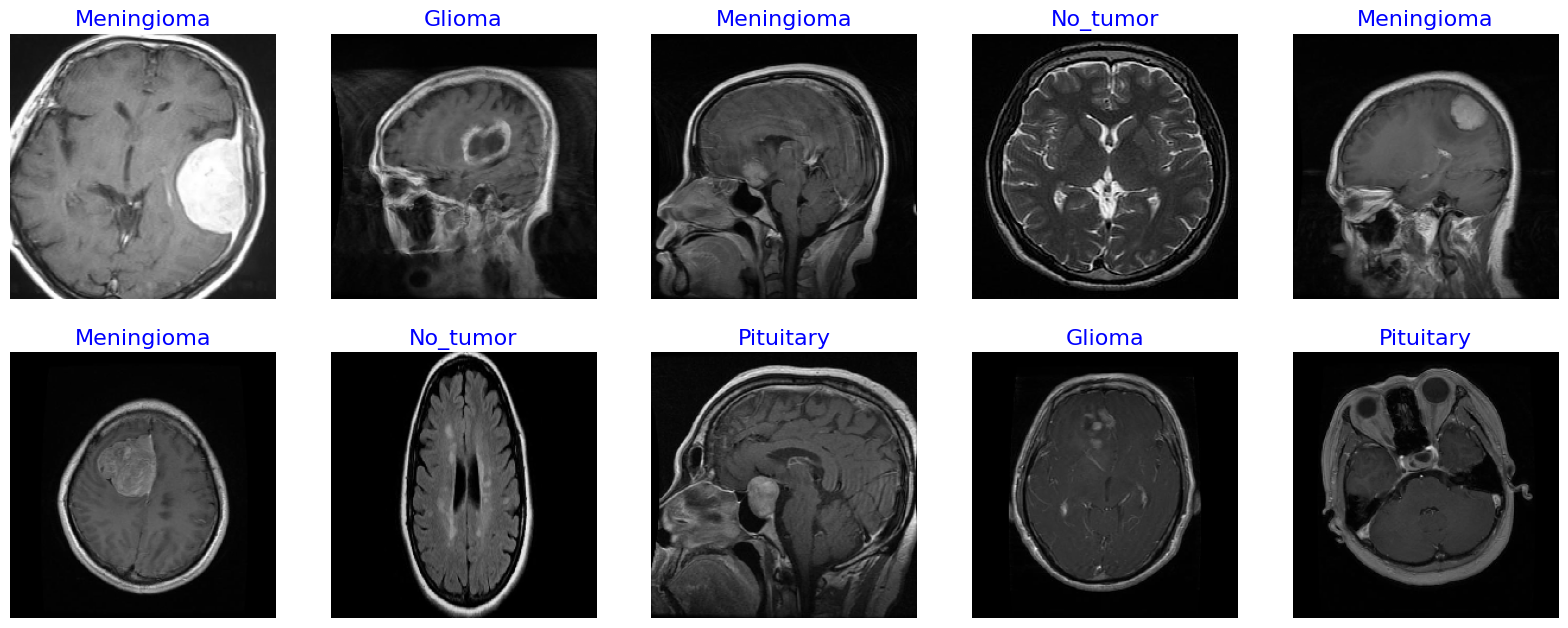

In [11]:
show_image_samples(train_gen)

In [12]:
import tensorflow as tf
import keras
import os
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras.utils import to_categorical
from keras.preprocessing import image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import metrics
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
import itertools
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

Model: "brain_res_inception_net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_18 (Conv2D)        │ (None, 111, 111, 32)   │            896 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_18    │ (None, 111, 111, 32)   │            128 │ conv2d_18[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_18             │ (None, 111, 111, 32)   │              0 │ batch_normalization_1… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_2           │ (None, 55, 55, 32)     │              0 │ activation_18[0][0]    │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_19 (Conv2D)        │ (None, 27, 27, 256)    │         73,984 │ max_pooling2d_2[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_19    │ (None, 27, 27, 256)    │          1,024 │ conv2d_19[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_19             │ (None, 27, 27, 256)    │              0 │ batch_normalization_1… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_23 (Conv2D)        │ (None, 27, 27, 16)     │          4,112 │ activation_19[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_23    │ (None, 27, 27, 16)     │             64 │ conv2d_23[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_23             │ (None, 27, 27, 16)     │              0 │ batch_normalization_2… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_21 (Conv2D)        │ (None, 27, 27, 16)     │          4,112 │ activation_19[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_24 (Conv2D)        │ (None, 27, 27, 16)     │          2,320 │ activation_23[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_21    │ (None, 27, 27, 16)     │             64 │ conv2d_21[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_24    │ (None, 27, 27, 16)     │             64 │ conv2d_24[0][0]        │
│ (BatchNormalization) 

 Total params: 12,053,540 (45.98 MB)

 Trainable params: 12,052,260 (45.98 MB)

 Non-trainable params: 1,280 (5.00 KB)

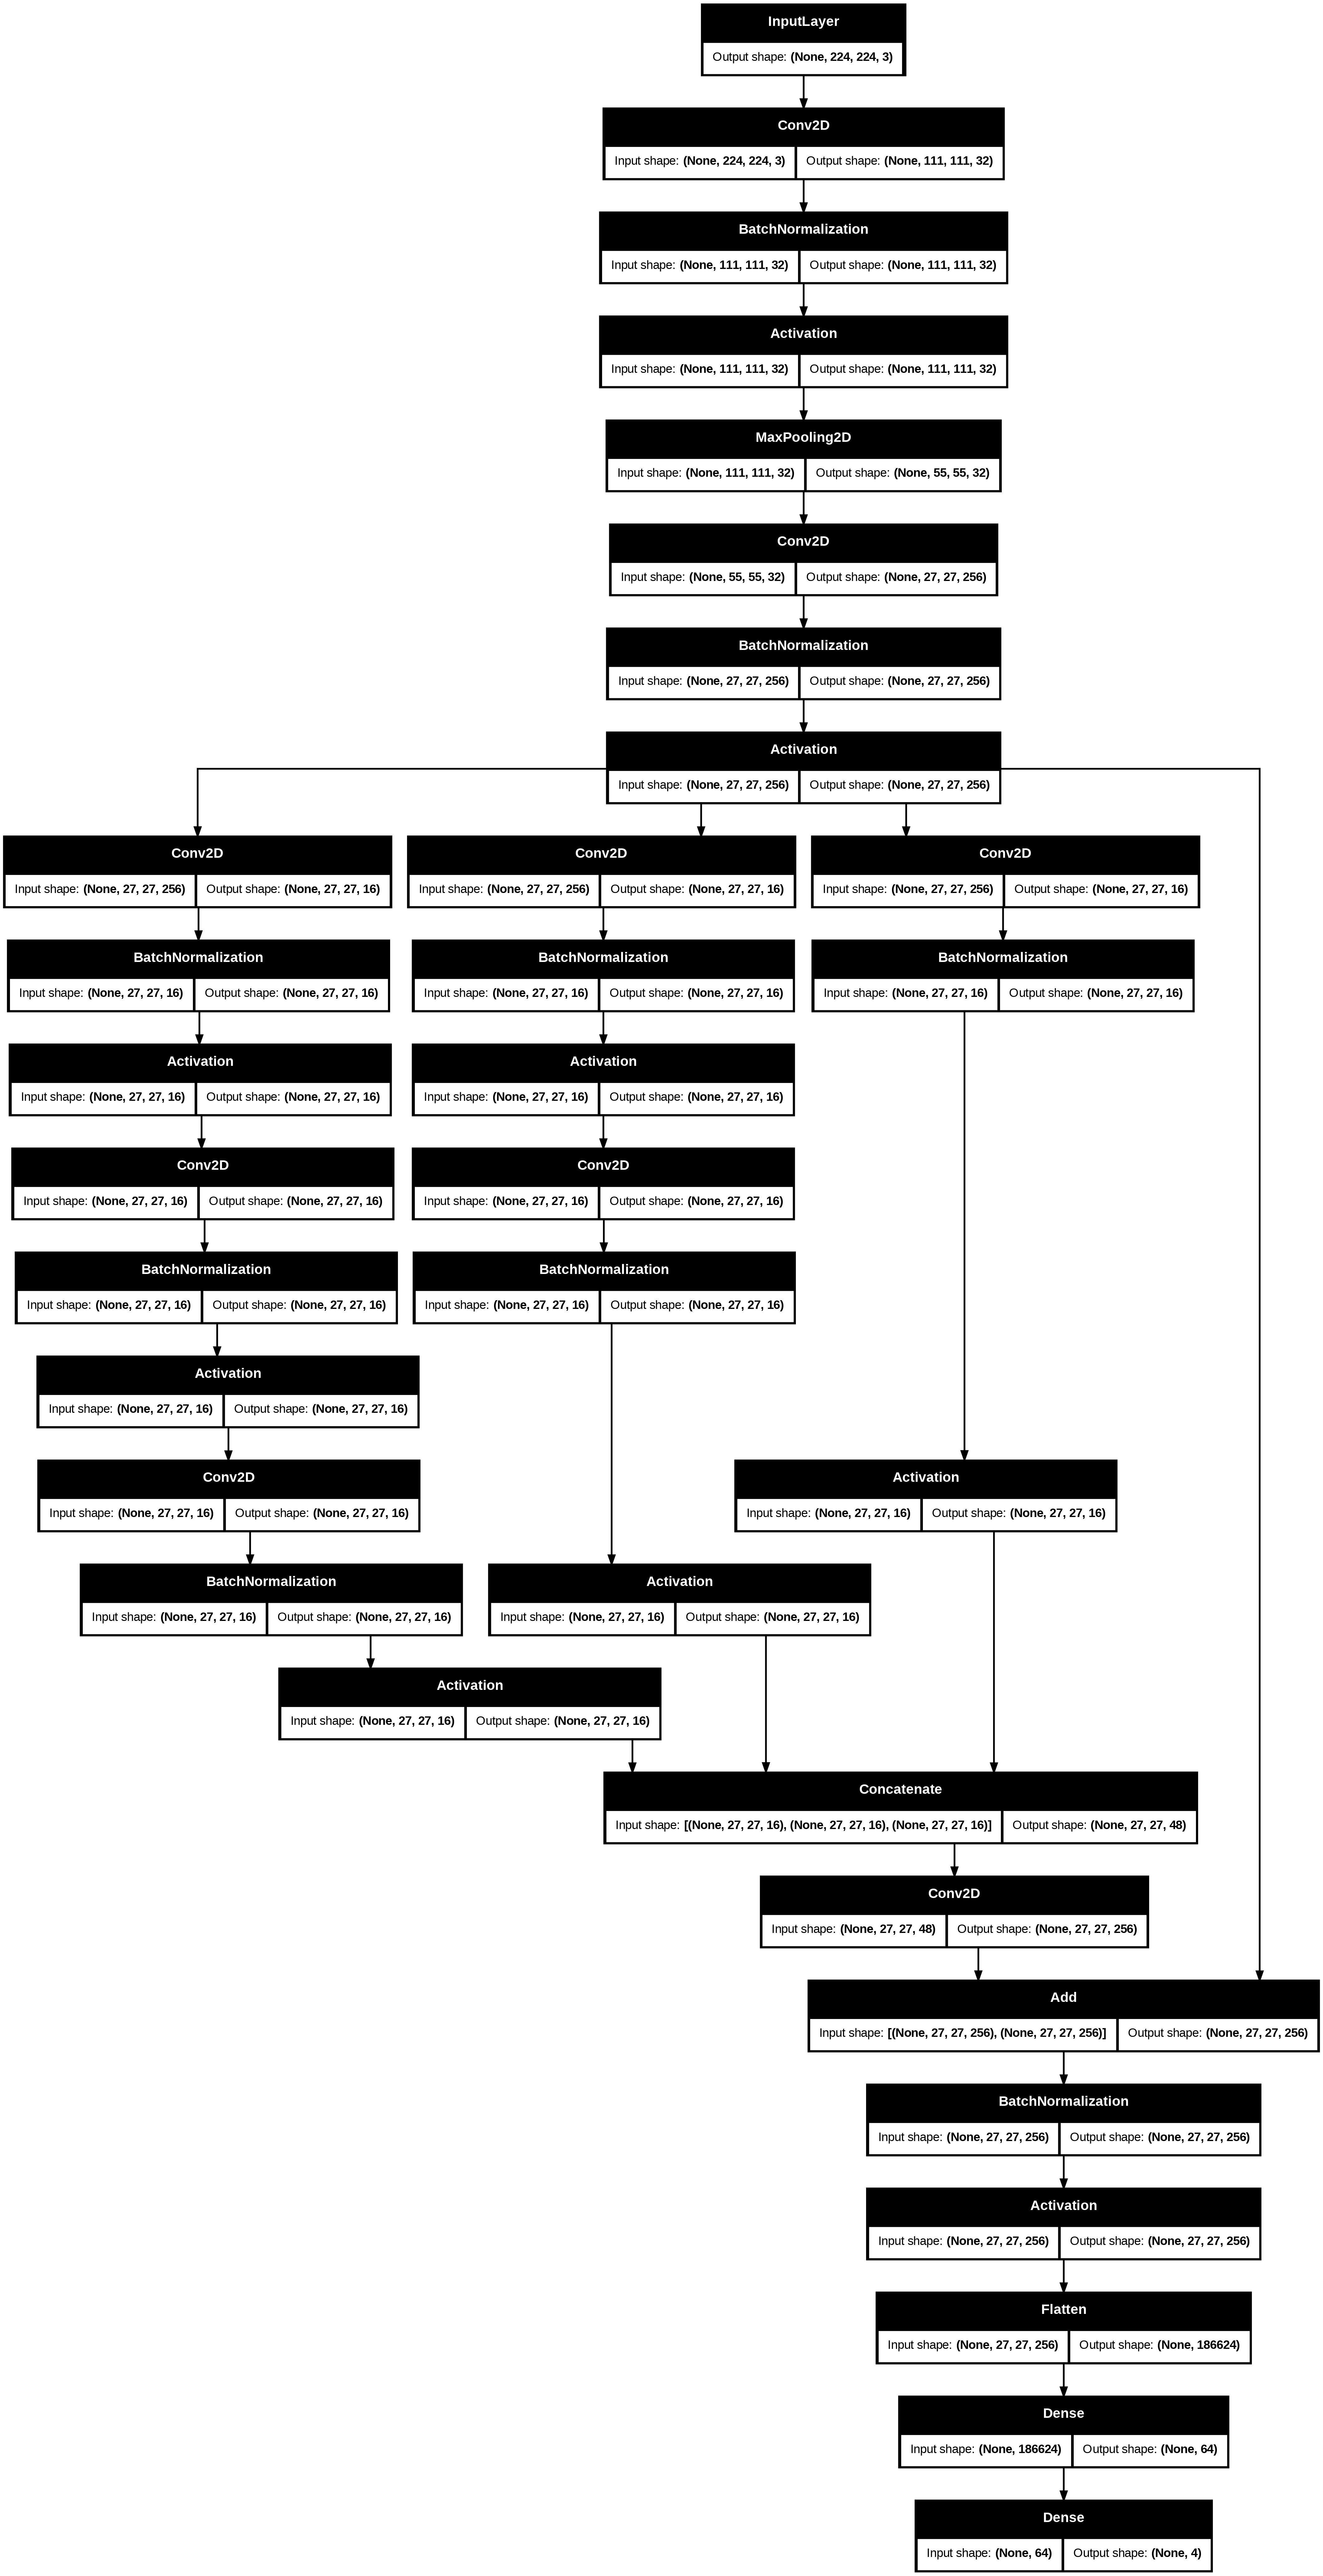

In [24]:
# -*- coding: utf-8 -*-
"""
Created on Mon Jan 27 20:06:49 2025

@author: WorkStation
"""
import tensorflow as tf
import tensorflow as tf
from tensorflow.keras import layers, regularizers

def Conv_2D_Block(x, model_width, kernel, strides=(1, 1), padding="same"):
    # 2D Convolutional Block with BatchNormalization
    x = tf.keras.layers.Conv2D(model_width, kernel, strides=strides, padding=padding, kernel_initializer="he_normal")(x)
    #x = tf.keras.layers.MaxPooling2D((3, 3), strides=(2, 2))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    return x


def Inception_ResNet_Module_A(inputs, filterB1_1, filterB2_1, filterB2_2, filterB3_1, filterB3_2, filterB3_3, filterB4_1, i):
    # Inception ResNet Module A - Block i
    branch1x1 = Conv_2D_Block(inputs, filterB1_1, (1, 1))

    branch3x3 = Conv_2D_Block(inputs, filterB2_1, (1, 1))
    branch3x3 = Conv_2D_Block(branch3x3, filterB2_2, (3, 3))

    branch3x3dbl = Conv_2D_Block(inputs, filterB3_1, (1, 1))
    branch3x3dbl = Conv_2D_Block(branch3x3dbl, filterB3_2, (3, 3))
    branch3x3dbl = Conv_2D_Block(branch3x3dbl, filterB3_3, (3, 3))

    branch_concat = tf.keras.layers.concatenate([branch1x1, branch3x3, branch3x3dbl], axis=-1)
    branch1x1_ln = tf.keras.layers.Conv2D(filterB4_1, (1, 1), activation='linear', strides=(1, 1), padding='same', kernel_initializer="he_normal")(branch_concat)

    x = tf.keras.layers.Add(name='Inception_ResNet_Block_A'+str(i))([inputs, branch1x1_ln])
    x = tf.keras.layers.BatchNormalization()(x)
    out = tf.keras.layers.Activation('relu')(x)

    return out


def Inception_ResNet_Module_B(inputs, filterB1_1, filterB2_1, filterB2_2, filterB2_3, filterB3_1, i):
    # Inception ResNet Module B - Block i
    branch1x1 = Conv_2D_Block(inputs, filterB1_1, (1, 1))

    branch7x7 = Conv_2D_Block(inputs, filterB2_1, (1, 1))
    branch7x7 = Conv_2D_Block(branch7x7, filterB2_2, (1, 7))
    branch7x7 = Conv_2D_Block(branch7x7, filterB2_3, (7, 1))

    branch_concat = tf.keras.layers.concatenate([branch1x1, branch7x7], axis=-1)
    branch1x1_ln = tf.keras.layers.Conv2D(filterB3_1, (1, 1), activation='linear', strides=(1, 1), padding='same', kernel_initializer="he_normal")(branch_concat)

    x = tf.keras.layers.Add(name='Inception_ResNet_Block_B'+str(i))([inputs, branch1x1_ln])
    x = tf.keras.layers.BatchNormalization()(x)
    out = tf.keras.layers.Activation('relu')(x)

    return out


def Inception_ResNet_Module_C(inputs, filterB1_1, filterB2_1, filterB2_2, filterB2_3, filterB3_1, i):
    # Inception ResNet Module C - Block i
    branch1x1 = Conv_2D_Block(inputs, filterB1_1, (1, 1))

    branch3x3 = Conv_2D_Block(inputs, filterB2_1, (1, 1))
    branch3x3 = Conv_2D_Block(branch3x3, filterB2_2, (1, 3))
    branch3x3 = Conv_2D_Block(branch3x3, filterB2_3, (3, 1))

    branch_concat = tf.keras.layers.concatenate([branch1x1, branch3x3], axis=-1)
    branch1x1_ln = tf.keras.layers.Conv2D(filterB3_1, (1, 1), activation='linear', strides=(1, 1), padding='same', kernel_initializer="he_normal")(branch_concat)

    x = tf.keras.layers.Add(name='Inception_ResNet_Block_C'+str(i))([inputs, branch1x1_ln])
    x = tf.keras.layers.BatchNormalization()(x)
    out = tf.keras.layers.Activation('relu')(x)

    return out


def Reduction_Block_A(inputs, filterB1_1, filterB2_1, filterB2_2, filterB2_3):
    # Reduction Block A
    branch_pool = tf.keras.layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2))(inputs)

    branch3x3 = Conv_2D_Block(inputs, filterB1_1, 3, strides=(2, 2), padding='valid')

    branch3x3dbl = Conv_2D_Block(inputs, filterB2_1, (1, 1))
    branch3x3dbl = Conv_2D_Block(branch3x3dbl, filterB2_2, (3, 3))
    branch3x3dbl = Conv_2D_Block(branch3x3dbl, filterB2_3, (3, 3), strides=(2, 2), padding='valid')

    x = tf.keras.layers.concatenate([branch_pool, branch3x3, branch3x3dbl], axis=-1, name='Reduction_Block_A')
    x = tf.keras.layers.BatchNormalization()(x)
    out = tf.keras.layers.Activation('relu')(x)

    return out


def Reduction_Block_B(inputs, filterB1_1, filterB1_2, filterB2_1, filterB2_2, filterB3_1, filterB3_2, filterB3_3):
    # Reduction Block B
    branch_pool = tf.keras.layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2))(inputs)

    branch3x3 = Conv_2D_Block(inputs, filterB1_1, (1, 1))
    branch3x3 = Conv_2D_Block(branch3x3, filterB1_2, (3, 3), strides=(2, 2), padding='valid')

    branch3x3_2 = Conv_2D_Block(inputs, filterB2_1, (1, 1))
    branch3x3_2 = Conv_2D_Block(branch3x3_2, filterB2_2, (3, 3), strides=(2, 2), padding='valid')

    branch3x3dbl = Conv_2D_Block(inputs, filterB3_1, (1, 1))
    branch3x3dbl = Conv_2D_Block(branch3x3dbl, filterB3_2, (3, 3))
    branch3x3dbl = Conv_2D_Block(branch3x3dbl, filterB3_3, (3, 3), strides=(2, 2), padding='valid')

    x = tf.keras.layers.concatenate([branch_pool, branch3x3, branch3x3_2, branch3x3dbl], axis=-1)
    x = tf.keras.layers.BatchNormalization()(x)
    out = tf.keras.layers.Activation('relu')(x)

    return out

inputs = tf.keras.Input((224, 224, 3))  # The input tensor
# Stem
x = Conv_2D_Block(inputs, 32, 3, strides=(2, 2), padding='valid')
#x = Conv_2D_Block(x, 32, 3, padding='valid')
#x = Conv_2D_Block(x, 64, 3)
x = tf.keras.layers.MaxPooling2D((3, 3), strides=(2, 2))(x)
#x=  tf.keras.layers.Dropout(.25)(x)
#x = Conv_2D_Block(x, 80, 1)
#x = Conv_2D_Block(x, 192, 3, padding='valid')
x = Conv_2D_Block(x, 256, 3, strides=(2, 2), padding='valid')
#x = tf.keras.layers.MaxPooling2D((3, 3), strides=(2, 2))(x)
# 5x Inception ResNet A Blocks - 35 x 35 x 256
for i in range(1):
    x = Inception_ResNet_Module_A(x, 16, 16, 16, 16, 16, 16, 256, i)


"""
x = Reduction_Block_A(x, 384, 192, 224, 256)  # Reduction Block A: 17 x 17 x 768

# 10x Inception ResNet B Blocks - 17 x 17 x 768
for i in range(1):
    x = Inception_ResNet_Module_B(x, 128, 128, 128, 128, 896, i)



x = Reduction_Block_B(x, 256, 384, 256, 256, 256, 256, 256)  # Reduction Block B: 8 x 8 x 1280

# 5x Inception ResNet C Blocks - 8 x 8 x 1280
for i in range(1):
    x = Inception_ResNet_Module_C(x, 128, 192, 192, 192, 1792, i)
"""
# Final Dense MLP Layer for the outputs
x = Flatten()(x)
#x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dense(64, activation='relu')(x)
#x=  tf.keras.layers.Dropout(.5)(x)
#x = tf.keras.layers.Dense(32, activation='relu')(x)
final_output = tf.keras.layers.Dense(4, activation='softmax')(x)
# Create model.
model = tf.keras.Model(inputs, final_output, name='brain_res_inception_net')


model.summary()

from keras.utils import plot_model
plot_model(model, show_shapes=True, to_file='inception_module.png')


In [25]:
from tensorflow.keras.metrics import Recall, Precision, AUC, RootMeanSquaredError
from sklearn.metrics import f1_score
from tensorflow.keras.optimizers import RMSprop,SGD
model.compile(SGD(learning_rate=.001), loss='categorical_crossentropy', metrics=['accuracy', Precision(), Recall(), AUC(), 'mae', 'mse', RootMeanSquaredError()])

In [ ]:
epochs =20
patience=9  # number of epochs to wait to adjust lr if monitored value does not improve
stop_patience =3 # number of epochs to wait before stopping training if monitored value does not improve
threshold=.9 # if train accuracy is < threshhold adjust monitor accuracy, else monitor validation loss
factor=.5 # factor to reduce lr by
dwell=True # experimental, if True and monitored metric does not improve on current epoch set  modelweights back to weights of previous epoch
freeze=False # if true free weights of  the base model
#callbacks=[LRA(model=model,patience=patience,stop_patience=stop_patience, threshold=threshold,
#                   factor=factor,dwell=dwell,model_name= model_name,  freeze=freeze, initial_epoch=0 )]
#LRA.tepochs=epochs  # used to determine value of last epoch for printing
history=model.fit(x=train_gen,  epochs=epochs, verbose=1,  validation_data=valid_gen,
               validation_steps=None,  shuffle=True,  initial_epoch=0)

In [27]:
def tr_plot(tr_data, start_epoch):
    #Plot the training and validation data
    tacc=tr_data.history['accuracy']
    tloss=tr_data.history['loss']
    vacc=tr_data.history['val_accuracy']
    vloss=tr_data.history['val_loss']
    Epoch_count=len(tacc)+ start_epoch
    Epochs=[]
    for i in range (start_epoch ,Epoch_count):
        Epochs.append(i+1)
    index_loss=np.argmin(vloss)#  this is the epoch with the lowest validation loss
    val_lowest=vloss[index_loss]
    index_acc=np.argmax(vacc)
    acc_highest=vacc[index_acc]
    plt.style.use('fivethirtyeight')
    sc_label='best epoch= '+ str(index_loss+1 +start_epoch)
    vc_label='best epoch= '+ str(index_acc + 1+ start_epoch)
    fig,axes=plt.subplots(nrows=1, ncols=2, figsize=(20,8))
    axes[0].plot(Epochs,tloss, 'r', label='Training loss')
    axes[0].plot(Epochs,vloss,'g',label='Validation loss' )
    axes[0].scatter(index_loss+1 +start_epoch,val_lowest, s=150, c= 'blue', label=sc_label)
    axes[0].set_title('Training and Validation Loss of Inception V3')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[1].plot (Epochs,tacc,'r',label= 'Training Accuracy')
    axes[1].plot (Epochs,vacc,'g',label= 'Validation Accuracy')
    axes[1].scatter(index_acc+1 +start_epoch,acc_highest, s=150, c= 'blue', label=vc_label)
    axes[1].set_title('Training and Validation Accuracy EBTDC-Net')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    plt.tight_layout
    #plt.style.use('fivethirtyeight')
    plt.show()

In [28]:
def print_info( test_gen, preds, print_code, save_dir, subject ):
    class_dict=test_gen.class_indices
    labels= test_gen.labels
    file_names= test_gen.filenames
    error_list=[]
    true_class=[]
    pred_class=[]
    prob_list=[]
    new_dict={}
    error_indices=[]
    y_pred=[]
    for key,value in class_dict.items():
        new_dict[value]=key             # dictionary {integer of class number: string of class name}
    # store new_dict as a text fine in the save_dir
    classes=list(new_dict.values())     # list of string of class names
    dict_as_text=str(new_dict)
    dict_name= subject + '-' +str(len(classes)) +'.txt'
    dict_path=os.path.join(save_dir,dict_name)
    with open(dict_path, 'w') as x_file:
        x_file.write(dict_as_text)
    errors=0
    for i, p in enumerate(preds):
        pred_index=np.argmax(p)
        true_index=labels[i]  # labels are integer values
        if pred_index != true_index: # a misclassification has occurred
            error_list.append(file_names[i])
            true_class.append(new_dict[true_index])
            pred_class.append(new_dict[pred_index])
            prob_list.append(p[pred_index])
            error_indices.append(true_index)
            errors=errors + 1
        y_pred.append(pred_index)
    if print_code !=0:
        if errors>0:
            if print_code>errors:
                r=errors
            else:
                r=print_code
            msg='{0:^28s}{1:^28s}{2:^28s}{3:^16s}'.format('Filename', 'Predicted Class' , 'True Class', 'Probability')
            print_in_color(msg, (0,255,0),(55,65,80))
            for i in range(r):
                split1=os.path.split(error_list[i])
                split2=os.path.split(split1[0])
                fname=split2[1] + '/' + split1[1]
                msg='{0:^28s}{1:^28s}{2:^28s}{3:4s}{4:^6.4f}'.format(fname, pred_class[i],true_class[i], ' ', prob_list[i])
                print_in_color(msg, (255,255,255), (55,65,60))
                #print(error_list[i]  , pred_class[i], true_class[i], prob_list[i])
        else:
            msg='With accuracy of 100 % there are no errors to print'
            print_in_color(msg, (0,255,0),(55,65,80))
    if errors>0:
        plot_bar=[]
        plot_class=[]
        for  key, value in new_dict.items():
            count=error_indices.count(key)
            if count!=0:
                plot_bar.append(count) # list containg how many times a class c had an error
                plot_class.append(value)   # stores the class
        fig=plt.figure()
        fig.set_figheight(len(plot_class)/3)
        fig.set_figwidth(10)
        plt.style.use('fivethirtyeight')
        for i in range(0, len(plot_class)):
            c=plot_class[i]
            x=plot_bar[i]
            plt.barh(c, x, )
            plt.title( ' Errors by Class on Test Set')
    y_true= np.array(labels)
    y_pred=np.array(y_pred)
    if len(classes)<= 30:
        # create a confusion matrix
        cm = confusion_matrix(y_true, y_pred )
        length=len(classes)
        if length<8:
            fig_width=8
            fig_height=8
        else:
            fig_width= int(length * .5)
            fig_height= int(length * .5)
        plt.figure(figsize=(fig_width, fig_height))
        sns.heatmap(cm, annot=True, vmin=0, fmt='g', cmap='Blues', cbar=False)
        plt.xticks(np.arange(length)+.5, classes, rotation= 90)
        plt.yticks(np.arange(length)+.5, classes, rotation=0)
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")
        plt.show()
    clr = classification_report(y_true, y_pred, target_names=classes)
    print("Classification Report:\n----------------------\n", clr)

In [ ]:
tr_plot(history,0)
save_dir=r'./'
subject='fruits'
acc=model.evaluate( test_gen, batch_size=test_batch_size, verbose=1, steps=test_steps, return_dict=False)[1]*100
msg=f'accuracy on the test set is {acc:5.2f} %'
print_in_color(msg, (0,255,0),(55,65,80))
save_id=str (model_name +  '-' + subject +'-'+ str(acc)[:str(acc).rfind('.')+3] + '.h5')
save_loc=os.path.join(save_dir, save_id)
model.save(save_loc)

print_code=0
preds=model.predict(test_gen)
print_info( test_gen, preds, print_code, save_dir, subject )